In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import time


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

##Import data
csvfile = 'marketing_campaign_cleaned_NODUMMIES'
df = pd.read_csv(csvfile)

#dummify
dummify_marital = pd.get_dummies(df['Marital_Status'],prefix='marital')
df = pd.concat([df, dummify_marital],axis=1)

dummify_edu = pd.get_dummies(df['Education'],prefix='education')
df = pd.concat([df, dummify_edu], axis=1)

# Drop transformed cols
df.drop(columns=['Marital_Status', 'Education'], inplace=True)

In [15]:


# Set seed for reproducibility
np.random.seed(0)

# Replace 'target' with your target column
X = df.drop('Response', axis=1)
y = df['Response']


# Define training set sizes
train_sizes = [0.0525, 0.105, 0.3, 0.5, 0.7]

# Define the metrics
metrics = {'accuracy': accuracy_score,
           'precision': precision_score,
           'recall': recall_score,
           'f1': f1_score,
           'roc_auc': roc_auc_score}

# Number of bootstrap iterations
n_iterations = 500

# Dict to store average scores and standard deviations for each metric
average_scores = {metric: [] for metric in metrics.keys()}
standard_deviations = {metric: [] for metric in metrics.keys()}

for size in train_sizes:
    # Bootstrap samples scores
    bootstrap_scores = {metric: [] for metric in metrics.keys()}
    print(size)
    for i in range(n_iterations):
        # Bootstrap sample
        
        
        start_time = time.time()
        # Set the size of your bootstrap sample. This could be the size of your original dataset
        bootstrap_size = int(0.7 * df.shape[0])

        # Perform bootstrapping
        df_train_full = resample(df, replace=True, n_samples=bootstrap_size, random_state=i*124)

        # Find the Out-of-Bag samples
        oob_index = df.index.difference(df_train.index)
        df_test = df.loc[oob_index]
        
        df_train_small = resample(df_train_full,replace=False,n_samples=int(size * len(df)))
                                  
        
        
     
        X_train = df_train_small.drop('Response', axis=1)
        y_train = df_train_small['Response']
        X_test = df_test.drop('Response', axis=1)
        y_test = df_test['Response']
                                  
        clf = RandomForestClassifier(n_estimators=500, max_depth=None, max_features='auto', criterion='gini', min_samples_split=2)

        # Fit and predict
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        for metric, function in metrics.items():
            # Compute metric score on bootstrap sample
            if metric == 'roc_auc':
                score = function(y_test, clf.predict_proba(X_test)[:, 1])
            else:
                score = function(y_test, y_pred)

            # Save score
            bootstrap_scores[metric].append(score)

    for metric in metrics.keys():
        # Compute average and standard deviation of metric scores
        average_scores[metric].append(np.mean(bootstrap_scores[metric]))
        standard_deviations[metric].append(np.std(bootstrap_scores[metric]))

# Creating a DataFrame to hold metric values
df_metrics = pd.DataFrame()





0.0525
0.105
0.3
0.5
0.7


In [16]:
# Let's assume df is your dataframe
df_len = len(df)

# This is your list
your_list = [0.0525, 0.105, 0.3, 0.5, 0.7]

# Multiply each element in the list by the length of the dataframe
result_list = [i * df_len for i in your_list]

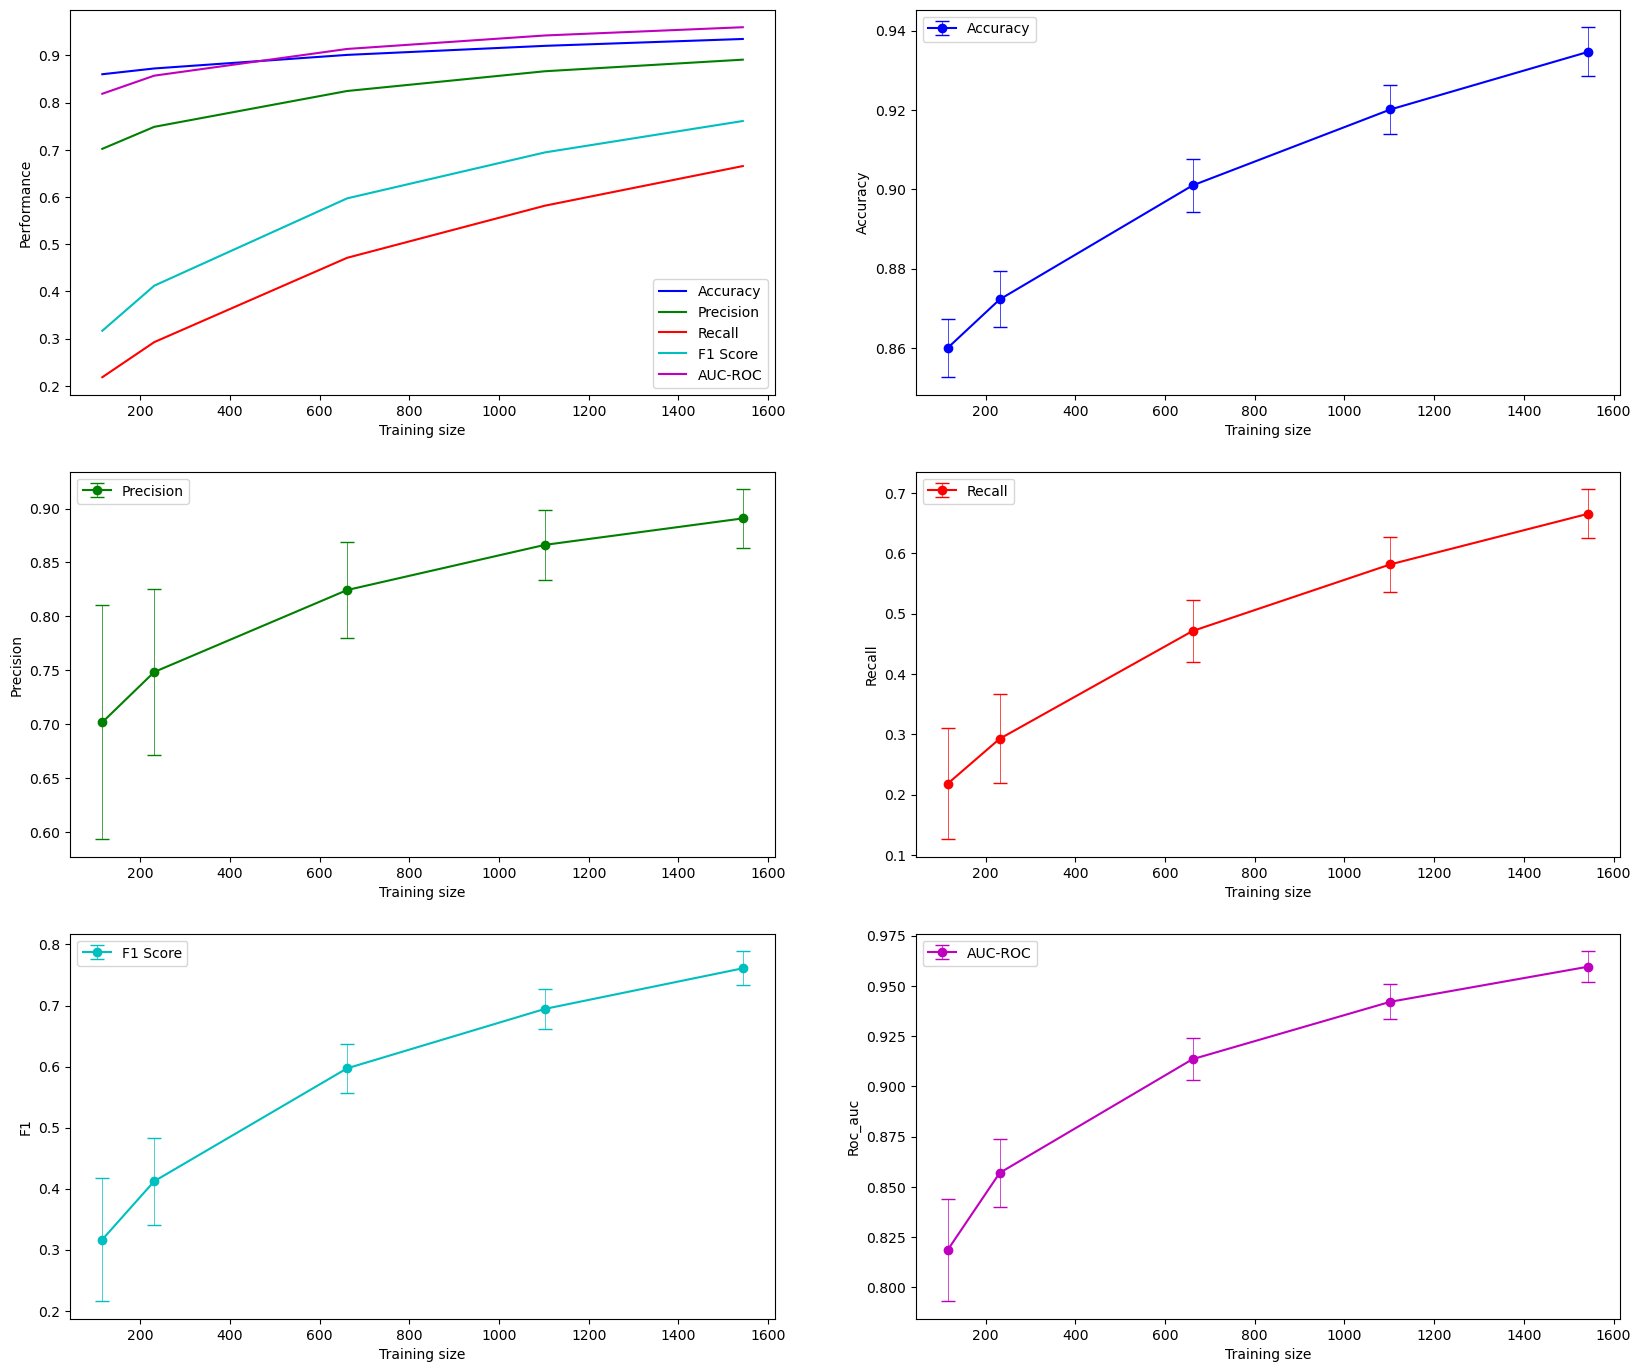

In [17]:
# Filling the DataFrame
for metric in metrics.keys():
    df_metrics[f'{metric}_mean'] = average_scores[metric]
    df_metrics[f'{metric}_std'] = standard_deviations[metric]

# Define colors for different metrics
colors = ['b', 'g', 'r', 'c', 'm', 'y']
metriclabels = ['Accuracy','Precision','Recall','F1 Score','AUC-ROC']

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,17))

# Flatten the axes for easier indexing
axes = axes.flatten()

# Plotting the graph on the first axis
for i, metric in enumerate(metrics.keys()):
    axes[0].plot(result_list, df_metrics[f'{metric}_mean'], color=colors[i], label=metriclabels[i])
axes[0].set_xlabel('Training size')
axes[0].set_ylabel('Performance')
axes[0].legend(loc='best')

# Move to the next axes for the error bars
for i, metric in enumerate(metrics.keys()):
    ax = axes[i+1]  # pick the current axis, starting from the second one

    ax.errorbar(result_list, df_metrics[f'{metric}_mean'], 
                yerr=df_metrics[f'{metric}_std'], 
                fmt='o-', color=colors[i], label=metriclabels[i], elinewidth=0.5, capsize=5)

    ax.set_xlabel('Training size')
    ax.set_ylabel(f'{metric.capitalize()}')
    ax.legend(loc='best')

# Save the entire figure instead of individual plots
plt.savefig('realdatabootstrap.png', bbox_inches='tight')

# Show the figure with all subplots
plt.show()